In [1]:
#beta 0 and beta 1 are found using optimization of the data aka OLS 
# you predict Y based on X
# perfect multicollinearity is when both the variables are exactly related to each other
#blue line is best linear unbiased estimate
# sum of the deviations is zero as they cancle each other out
#SUM OF THE SQUARED ERRORS - bigger the number pooere fit to the data
#SSE always lower than SSTotal
#r^2 = 1-sse/sst
##r^2 ranges from 0 to 1; 1 when sse is 0 ie the line goes through all the points but is nearly impossible for a straight line hence why it is a limitation of liner regression
#it is a techinque designed to find a line that ....

In [2]:
#F = ((sst - sse)/p)/(sse/(n - p - 1))
#t = b1/se(b1); where b1 id estimate of coefficients for first predictor
#statsmodels good for INFERENce; scikitlearn better for PREDICTING

In [3]:
import pandas as pd
data = pd.read_csv('/Users/chintanjikkar/Desktop/PACE/Fall 25/Predictive Analytics/codes/Data/earning.csv')

In [4]:
train = data.sample(frac = 0.7, random_state = 617)
test = data.drop(train.index)
len(train), len(test), len(data)
#the len function is to check if the data is exactly the same as per the train adn test data sets created
#if you dont mention the index it takes it via lexical order

(1250, 535, 1785)

In [5]:
train = data.sample(frac = 0.7, random_state = 617)
test = data.drop(labels=train.index)

In [6]:
train.dtypes
#object as in those have categorical data in this scenario as M/Fe and || for ethni

earn          int64
age           int64
gender       object
height        int64
weight        int64
ethnicity    object
education     int64
walk          int64
exercise      int64
smokenow      int64
tense         int64
dtype: object

In [7]:
!pip show seaborn

Name: seaborn
Version: 0.13.2
Summary: Statistical data visualization
Home-page: 
Author: 
Author-email: Michael Waskom <mwaskom@gmail.com>
License: 
Location: /opt/anaconda3/lib/python3.13/site-packages
Requires: matplotlib, numpy, pandas
Required-by: 


In [8]:
import matplotlib.pyplot as plt
import numpy as np
!pip install seaborn

In [9]:
#INSTALLED SEABORN IN PRED_ENV TO SOLVE THIS- it was getting installed in base.env hence the issue
#EXACT CODE:    % conda activate pred_env  XXX  conda install seaborn  XXX y XXX DONE
#%conda install -c conda-forge seaborn #not necessarily req can just do it in terminal

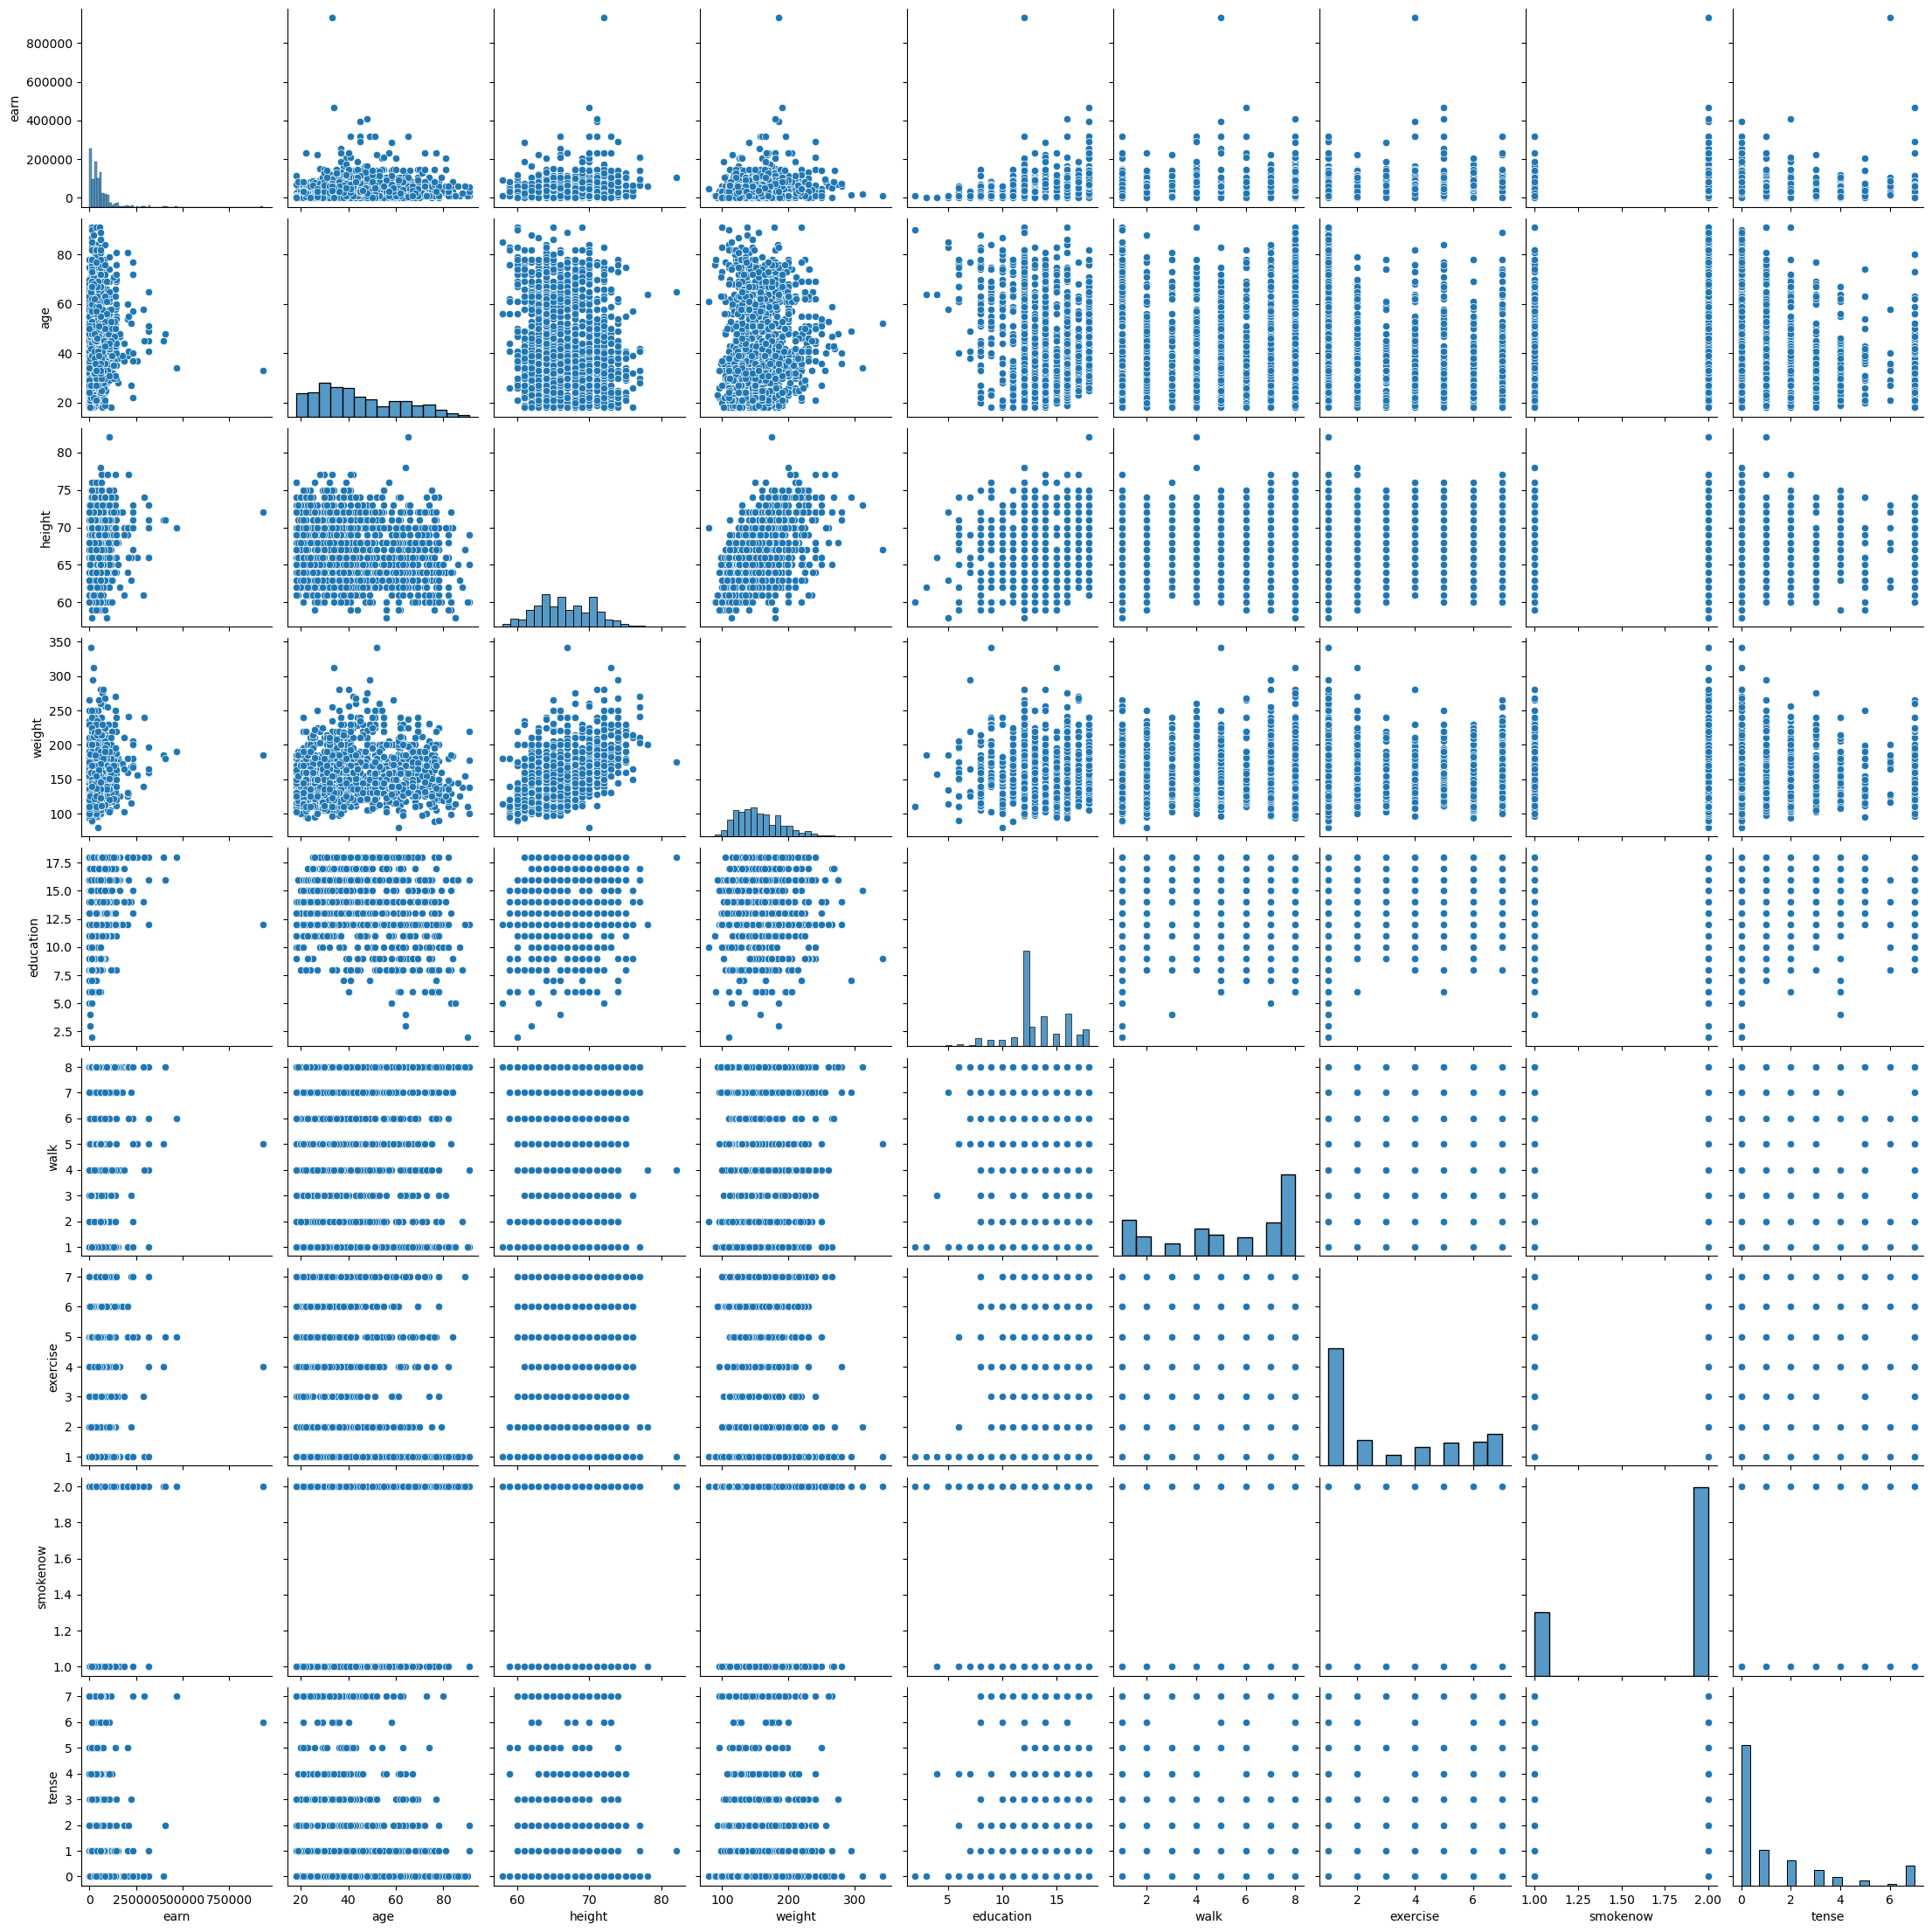

In [10]:
import seaborn as sns
sns.pairplot(train)
plt.show()

In [11]:
#predictor Xaxis and variable Yaxis

In [12]:
train.select_dtypes('int').corr()
#it gives you all the matrix of correlation between variables
#pearsons product movement correlation 

,earn,age,height,weight,education,walk,exercise,smokenow,tense
earn,1.000000,0.060472,0.250444,0.152521,0.313749,0.034150,0.080984,0.039708,-0.041476
age,0.060472,1.000000,-0.133450,0.102973,-0.152405,0.020260,-0.338540,0.078346,-0.256751
height,0.250444,-0.133450,1.000000,0.536751,0.136924,0.060131,0.196302,-0.047978,-0.094288
weight,0.152521,0.102973,0.536751,1.000000,0.014005,0.003015,-0.026924,0.049121,-0.079610
education,0.313749,-0.152405,0.136924,0.014005,1.000000,0.061678,0.173327,0.127476,-0.008053
walk,0.034150,0.020260,0.060131,0.003015,0.061678,1.000000,0.179038,0.061457,-0.045031
exercise,0.080984,-0.338540,0.196302,-0.026924,0.173327,0.179038,1.000000,0.038663,0.006154
smokenow,0.039708,0.078346,-0.047978,0.049121,0.127476,0.061457,0.038663,1.000000,-0.091197
tense,-0.041476,-0.256751,-0.094288,-0.079610,-0.008053,-0.045031,0.006154,-0.091197,1.000000


In [13]:
from statsmodels.formula.api import ols

In [14]:
reg = ols('earn ~ height', data = train)
model = reg.fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   earn   R-squared:                       0.063
Model:                            OLS   Adj. R-squared:                  0.062
Method:                 Least Squares   F-statistic:                     83.52
Date:                Thu, 16 Oct 2025   Prob (F-statistic):           2.49e-19
Time:                        14:09:41   Log-Likelihood:                -15360.
No. Observations:                1250   AIC:                         3.072e+04
Df Residuals:                    1248   BIC:                         3.073e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept  -1.862e+05   2.58e+04     -7.219      0.000   -2.37e+05   -1.36e+05
height      3531.8627    386.473      9.139      0.000    2773.654    4290.072
==============================================================================
Omnibus:                     1436.431   Durbin-Watson:                   1.993
Prob(Omnibus):                  0.000   Jarque-Bera (JB):           234476.061
Skew:                           5.501   Prob(JB):                         0.00
Kurtosis:                      69.188   Cond. No.                     1.16e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.16e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [15]:
print('earn=', model.params.iloc[0], '+ height*', model.params.iloc[1])

earn= -186191.27781557228 + height* 3531.8627309119693


In [16]:
model.predict()

array([78698.42700283, 61039.11334827, 43379.79969371, ...,
       50443.52515553, 39847.93696279, 46911.66242462], shape=(1250,))

In [17]:
(
    train.loc[:,['height','earn']]
        .assign(pred = model.predict(),
                e = train.earn - model.predict(),
                se = (train.earn - model.predict())**2) 
        .head()
)
#this will predict the salaries...!?

,height,earn,pred,e,se
384,75,7437,78698.427003,-71261.427003,5.078191e+09
621,70,144460,61039.113348,83420.886652,6.959044e+09
1331,65,0,43379.799694,-43379.799694,1.881807e+09
1264,59,34950,22188.623308,12761.376692,1.628527e+08
268,67,53590,50443.525156,3146.474844,9.900304e+06


In [18]:
heights_data = pd.DataFrame({'cost':[1],
                            'height': [75]})
model.predict(heights_data)
#predicted value of height 75inch

0    78698.427003
dtype: float64

In [19]:
heights_data = pd.DataFrame({'const':[1,1,1],
                            'height':[75,76,77]})
model.predict(heights_data)

0    78698.427003
1    82230.289734
2    85762.152465
dtype: float64

In [20]:
model.predict(heights_data).diff()
#diff is the difference of consecutive numbers ie with every additional inch the earnings is increasing by 3531 

0            NaN
1    3531.862731
2    3531.862731
dtype: float64

In [21]:
reg = ols('earn ~ gender', data = train)
model = reg.fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   earn   R-squared:                       0.091
Model:                            OLS   Adj. R-squared:                  0.090
Method:                 Least Squares   F-statistic:                     124.6
Date:                Thu, 16 Oct 2025   Prob (F-statistic):           1.19e-27
Time:                        14:09:41   Log-Likelihood:                -15341.
No. Observations:                1250   AIC:                         3.069e+04
Df Residuals:                    1248   BIC:                         3.070e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==================================================================================
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept       3.643e+04   1854.527     19.642      0.000    3.28e+04    4.01e+04
gender[T.male]  3.373e+04   3021.188     11.164      0.000    2.78e+04    3.97e+04
==============================================================================
Omnibus:                     1453.941   Durbin-Watson:                   1.977
Prob(Omnibus):                  0.000   Jarque-Bera (JB):           255035.108
Skew:                           5.596   Prob(JB):                         0.00
Kurtosis:                      72.075   Cond. No.                         2.43
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [22]:
train.gender.value_counts()
#the one thats earlier alphabeticalluy is taken as the default dummy and the other is taken into account (T-1malevariable) number of dummies 

gender
female    779
male      471
Name: count, dtype: int64

In [23]:
print('earn=', model.params.iloc[0], '+ gender_male*', model.params.iloc[1])

earn= 36426.62130937086 + gender_male* 33727.97741674402


In [24]:
train.ethnicity.value_counts()
#A for African Am is taken as default dummy

ethnicity
White               1031
African American     121
Hispanic              78
Asian                 20
Name: count, dtype: int64

In [25]:
reg = ols('earn ~ ethnicity', data = train)
model = reg.fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   earn   R-squared:                       0.008
Model:                            OLS   Adj. R-squared:                  0.006
Method:                 Least Squares   F-statistic:                     3.375
Date:                Thu, 16 Oct 2025   Prob (F-statistic):             0.0178
Time:                        14:09:41   Log-Likelihood:                -15395.
No. Observations:                1250   AIC:                         3.080e+04
Df Residuals:                    1246   BIC:                         3.082e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
=========================================================================================
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept              4.046e+04   4918.917      8.226      0.000    3.08e+04    5.01e+04
ethnicity[T.Asian]    -3948.0169   1.31e+04     -0.302      0.762   -2.96e+04    2.17e+04
ethnicity[T.Hispanic] -3885.9413   7856.855     -0.495      0.621   -1.93e+04    1.15e+04
ethnicity[T.White]     1.089e+04   5199.558      2.094      0.036     686.641    2.11e+04
==============================================================================
Omnibus:                     1421.294   Durbin-Watson:                   1.988
Prob(Omnibus):                  0.000   Jarque-Bera (JB):           219279.940
Skew:                           5.418   Prob(JB):                         0.00
Kurtosis:                      66.975   Cond. No.                         11.8
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [26]:
reg = ols('earn ~ height + gender', data = train)
model = reg.fit()
model.summary()
# this is a show of how you can use multiple variables as independent to regress the predictive ones

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   earn   R-squared:                       0.094
Model:                            OLS   Adj. R-squared:                  0.093
Method:                 Least Squares   F-statistic:                     64.78
Date:                Thu, 16 Oct 2025   Prob (F-statistic):           1.72e-27
Time:                        14:09:41   Log-Likelihood:                -15338.
No. Observations:                1250   AIC:                         3.068e+04
Df Residuals:                    1247   BIC:                         3.070e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==================================================================================
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept      -3.635e+04   3.41e+04     -1.066      0.287   -1.03e+05    3.06e+04
gender[T.male]  2.752e+04   4186.910      6.574      0.000    1.93e+04    3.57e+04
height          1127.3513    527.511      2.137      0.033      92.444    2162.259
==============================================================================
Omnibus:                     1453.251   Durbin-Watson:                   1.978
Prob(Omnibus):                  0.000   Jarque-Bera (JB):           254049.189
Skew:                           5.593   Prob(JB):                         0.00
Kurtosis:                      71.939   Cond. No.                     1.56e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.56e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [27]:
reg = ols('earn ~ height + gender + height*gender', data = train)
model = reg.fit()
model.summary()
#this height*gender variable is ...?

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   earn   R-squared:                       0.096
Model:                            OLS   Adj. R-squared:                  0.094
Method:                 Least Squares   F-statistic:                     43.97
Date:                Thu, 16 Oct 2025   Prob (F-statistic):           5.19e-27
Time:                        14:09:42   Log-Likelihood:                -15337.
No. Observations:                1250   AIC:                         3.068e+04
Df Residuals:                    1246   BIC:                         3.070e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
=========================================================================================
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept              9661.6534   4.59e+04      0.210      0.833   -8.04e+04    9.97e+04
gender[T.male]        -7.962e+04   7.18e+04     -1.110      0.267    -2.2e+05    6.12e+04
height                  414.6018    710.677      0.583      0.560    -979.654    1808.857
height:gender[T.male]  1585.3408   1059.901      1.496      0.135    -494.046    3664.728
==============================================================================
Omnibus:                     1451.182   Durbin-Watson:                   1.980
Prob(Omnibus):                  0.000   Jarque-Bera (JB):           252202.246
Skew:                           5.580   Prob(JB):                         0.00
Kurtosis:                      71.686   Cond. No.                     3.98e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 3.98e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [28]:
reg = ols('earn ~ weight + gender + weight*gender', data = train)
model = reg.fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   earn   R-squared:                       0.098
Model:                            OLS   Adj. R-squared:                  0.095
Method:                 Least Squares   F-statistic:                     44.88
Date:                Thu, 16 Oct 2025   Prob (F-statistic):           1.53e-27
Time:                        14:09:43   Log-Likelihood:                -15336.
No. Observations:                1250   AIC:                         3.068e+04
Df Residuals:                    1246   BIC:                         3.070e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
=========================================================================================
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept              4.751e+04   8845.920      5.371      0.000    3.02e+04    6.49e+04
gender[T.male]        -1.478e+04   1.63e+04     -0.904      0.366   -4.68e+04    1.73e+04
weight                  -76.8149     59.933     -1.282      0.200    -194.395      40.766
weight:gender[T.male]   288.7331     97.295      2.968      0.003      97.853     479.613
==============================================================================
Omnibus:                     1457.188   Durbin-Watson:                   1.983
Prob(Omnibus):                  0.000   Jarque-Bera (JB):           258131.249
Skew:                           5.616   Prob(JB):                         0.00
Kurtosis:                      72.498   Cond. No.                     2.13e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.13e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [29]:
reg = ols('earn ~ age + gender + height + weight + ethnicity + education + walk + exercise + smokenow + tense', data = train)
model = reg.fit()

model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   earn   R-squared:                       0.200
Model:                            OLS   Adj. R-squared:                  0.193
Method:                 Least Squares   F-statistic:                     25.82
Date:                Thu, 16 Oct 2025   Prob (F-statistic):           2.38e-52
Time:                        14:09:43   Log-Likelihood:                -15260.
No. Observations:                1250   AIC:                         3.055e+04
Df Residuals:                    1237   BIC:                         3.061e+04
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
=========================================================================================
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept               -1.1e+05   3.56e+04     -3.093      0.002    -1.8e+05   -4.02e+04
gender[T.male]         3.086e+04   4089.922      7.546      0.000    2.28e+04    3.89e+04
ethnicity[T.Asian]    -5419.4781   1.19e+04     -0.456      0.648   -2.87e+04    1.79e+04
ethnicity[T.Hispanic] -1054.8210   7189.010     -0.147      0.883   -1.52e+04     1.3e+04
ethnicity[T.White]     5336.7189   4738.480      1.126      0.260   -3959.627    1.46e+04
age                     445.7606     90.864      4.906      0.000     267.495     624.026
height                  562.1321    555.369      1.012      0.312    -527.436    1651.701
weight                  -13.8389     49.423     -0.280      0.780    -110.800      83.122
education              6471.9786    557.408     11.611      0.000    5378.409    7565.548
walk                   -113.6744    542.884     -0.209      0.834   -1178.749     951.400
exercise                298.6003    671.630      0.445      0.657   -1019.060    1616.260
smokenow                638.9624   3263.319      0.196      0.845   -5763.289    7041.214
tense                  1221.4603    699.545      1.746      0.081    -150.965    2593.886
==============================================================================
Omnibus:                     1563.813   Durbin-Watson:                   1.990
Prob(Omnibus):                  0.000   Jarque-Bera (JB):           411216.690
Skew:                           6.246   Prob(JB):                         0.00
Kurtosis:                      90.973   Cond. No.                     4.64e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 4.64e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [30]:
X = data.drop(labels = 'earn', axis=1)
y = data.earn

from sklearn.model_selection import train_test_split

train_test_split(X,y, 
                train_size=0.7, 
                random_state=617, 
                stratify=pd.qcut(y,5))

[      age  gender  height  weight         ethnicity  education  walk  \
 243    37  female      64     170             White         12     8   
 543    65    male      82     175             White         18     4   
 1064   46  female      68     160             White         12     6   
 211    42  female      62     150  African American         15     2   
 580    37  female      61     102             White         13     8   
 ...   ...     ...     ...     ...               ...        ...   ...   
 1443   62  female      66     185             White         14     8   
 915    40  female      62     135             White         15     1   
 317    51    male      71     190             White         14     8   
 900    33  female      63     115             White         16     2   
 919    23  female      67     140             White         14     4   
 
       exercise  smokenow  tense  
 243          1         2      7  
 543          1         2      1  
 1064         1  

In [31]:
X = data.drop(labels = 'earn', axis=1)
y = data.earn

from sklearn.model_selection import train_test_split

X_train_raw, X_test_raw, y_train, y_test = train_test_split(X,y, 
                                                            train_size=0.7, 
                                                            random_state=617, 
                                                            stratify=pd.qcut(y,5))

In [32]:
X_train_raw.head()

,age,gender,height,weight,ethnicity,education,walk,exercise,smokenow,tense
243,37,female,64,170,White,12,8,1,2,7
543,65,male,82,175,White,18,4,1,2,1
1064,46,female,68,160,White,12,6,1,2,7
211,42,female,62,150,African American,15,2,1,2,2
580,37,female,61,102,White,13,8,4,1,2


In [33]:
pd.get_dummies(X_train_raw, columns= ['gender', 'ethnicity'], drop_first=True).head()
#if you dont add dropfirst or keep it falsi it is called one hot encoding as it takes both the data points

,age,height,weight,education,walk,exercise,smokenow,tense,gender_male,ethnicity_Asian,ethnicity_Hispanic,ethnicity_White
243,37,64,170,12,8,1,2,7,False,False,False,True
543,65,82,175,18,4,1,2,1,True,False,False,True
1064,46,68,160,12,6,1,2,7,False,False,False,True
211,42,62,150,15,2,1,2,2,False,False,False,False
580,37,61,102,13,8,4,1,2,False,False,False,True


In [34]:
categorical_features = ['gender','ethnicity','smokenow']

X_train = pd.get_dummies(X_train_raw, 
                         prefix_sep = '_', 
                         columns = categorical_features, 
                         drop_first = True)

X_test = pd.get_dummies(X_test_raw, 
                         prefix_sep = '_', 
                         columns = categorical_features, 
                         drop_first = True)

X_test.reindex(columns=X_train.columns, fill_value=0)
X_train.head()
#this(last 2 lines) ensures that train and test sample are aligning ie we arent missing in the train sample completely but is in the test sample

,age,height,weight,education,walk,exercise,tense,gender_male,ethnicity_Asian,ethnicity_Hispanic,ethnicity_White,smokenow_2
243,37,64,170,12,8,1,7,False,False,False,True,True
543,65,82,175,18,4,1,1,True,False,False,True,True
1064,46,68,160,12,6,1,7,False,False,False,True,True
211,42,62,150,15,2,1,2,False,False,False,False,True
580,37,61,102,13,8,4,2,False,False,False,True,False


In [35]:
y_binned = pd.cut(x = y, bins = [-1,20000,40000,60000,80000, 100000, 200000,1000000])  # specifying bins because the earn is skewed
from sklearn.model_selection import train_test_split
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y, 
                                                    train_size=0.7, 
                                                    random_state=617, stratify = y_binned)
##this is just cause

In [36]:
from sklearn.linear_model import LinearRegression

In [37]:
reg = LinearRegression()

In [38]:
reg.fit(X_train,y_train)
reg

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [39]:
y_pred = reg.predict(X_train)

In [40]:
np.sqrt(np.mean((y_pred - y_train)**2))
##this is just plain old RMSE in its true glory though cumbersome and basic so wont be using it

np.float64(53061.304622413736)

In [41]:
from sklearn.metrics import root_mean_squared_error
root_mean_squared_error(y_train, y_pred)
##SAME as the previous error

53061.304622413736

In [42]:
####  SOMETHING AMISS???
reg.fit(X_train.loc[:,['age', 'height']], y_train)
y_pred = reg.predict(X_train)
y_pred_test = reg.predict(X_test)

ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- education
- ethnicity_Asian
- ethnicity_Hispanic
- ethnicity_White
- exercise
- ...


In [43]:
root_mean_squared_error(y_train, y_pred), root_mean_squared_error(y_test, y_pred_test)

NameError: name 'y_pred_test' is not defined

In [44]:
####FULL DEAL FROM START TO END ####

In [45]:
import pandas as pd
data = pd.read_csv('/Users/chintanjikkar/Desktop/PACE/Fall 25/Predictive Analytics/codes/Data/earning.csv')
categorical_features = ['gender','ethnicity','smokenow']
y_binned = pd.cut(x = y, bins = [-1,20000,40000,60000,80000, 100000, 200000,1000000])  # specifying bins because the earn is skewed
from sklearn.model_selection import train_test_split
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y, 
                                                    train_size=0.7, 
                                                    random_state=617, stratify = y_binned)

X_train = pd.get_dummies(X_train_raw, 
                         prefix_sep = '_', 
                         columns = categorical_features, 
                         drop_first = True)

X_test = pd.get_dummies(X_test_raw, 
                         prefix_sep = '_', 
                         columns = categorical_features, 
                         drop_first = True)

X_test.reindex(columns=X_train.columns, fill_value=0)
X_train.head()

from sklearn.linear_model import LinearRegression
reg = LinearRegression()
reg.fit(X_train.loc[:,['age', 'height']], y_train)
y_pred = reg.predict(X_train.loc[:,['age','height']])
y_pred_test = reg.predict(X_test.loc[:,['age','height']])

from sklearn.metrics import root_mean_squared_error
root_mean_squared_error(y_train, y_pred), root_mean_squared_error(y_test, y_pred_test)

(50640.462035146425, 50107.5555710539)